# Module 04: Seaborn for Machine Learning
## Notebook 02: Relational and Categorical Statistical Plots

Machine learning datasets mix numerical measurements with discrete categorical factors. Seaborn excels at encoding multiple variables into visual dimensions (color, shape, size) and displaying categorical distributions with statistical confidence intervals.

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Construct multi-variable **Relational Plots** using `hue`, `style`, and `size`.
2. Generate time series line plots with automated bootstrap **confidence intervals**.
3. Compare distributions across categories using **Box Plots** and **Violin Plots**.
4. Visualize raw individual observations using **Strip Plots** and **Swarm Plots**.
5. Build statistical point estimates with `sns.barplot()` and frequency distributions with `sns.countplot()`.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid", palette="deep")
print("Seaborn loaded!")

Seaborn loaded!


### 1. Multi-Variable Relational Plots: `sns.scatterplot()`

A single 2D scatter plot can encode up to **5 variables simultaneously**:
1. $x$-axis: Feature 1 (e.g. Engine Displacement)
2. $y$-axis: Feature 2 (e.g. Horsepower)
3. `hue`: Target Class or Category (e.g. Vehicle Origin)
4. `style`: Secondary Category (e.g. Transmission Type)
5. `size`: Continuous Quantity (e.g. Vehicle Weight)

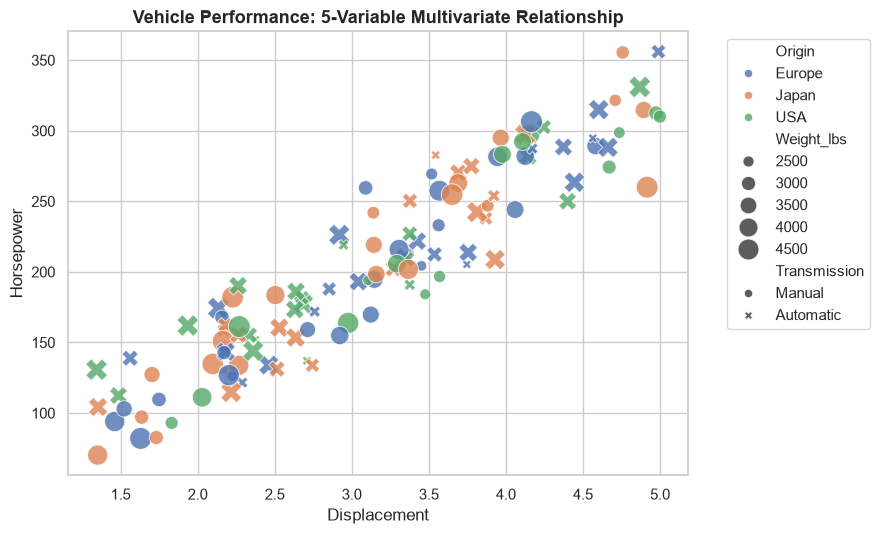

In [2]:
rng = np.random.default_rng(99)
N = 120

df_cars = pd.DataFrame({
    'Displacement': rng.uniform(1.2, 5.0, size=N),
    'Horsepower': rng.uniform(90, 450, size=N),
    'Weight_lbs': rng.uniform(2200, 4800, size=N),
    'Origin': rng.choice(['USA', 'Europe', 'Japan'], size=N),
    'Transmission': rng.choice(['Automatic', 'Manual'], size=N)
})
# Introduce correlation
df_cars['Horsepower'] = df_cars['Displacement'] * 65 + rng.normal(0, 25, size=N)

fig, ax = plt.subplots(figsize=(9, 5.5))

sns.scatterplot(
    data=df_cars,
    x='Displacement',
    y='Horsepower',
    hue='Origin',
    style='Transmission',
    size='Weight_lbs',
    sizes=(40, 250),
    alpha=0.8,
    ax=ax
)

ax.set_title("Vehicle Performance: 5-Variable Multivariate Relationship", fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

---
### 2. Time Series with Automated Confidence Bands: `sns.lineplot()`

When data has multiple observations per timestep (e.g., repeating an experiment across 5 random seeds), `sns.lineplot()` automatically aggregates by mean and plots a **95% bootstrap confidence interval band**!

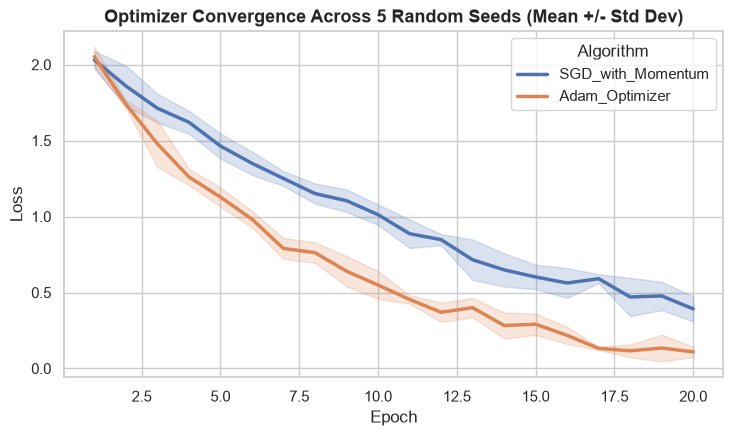

In [3]:
# Simulating multiple experimental runs of two optimization algorithms
runs = []
for algo in ['SGD_with_Momentum', 'Adam_Optimizer']:
    for seed in range(5):
        loss_curve = 2.0 * np.exp(- (0.15 if algo == 'Adam_Optimizer' else 0.08) * np.arange(20)) + np.random.normal(0, 0.08, 20)
        for epoch, loss in enumerate(loss_curve):
            runs.append({'Algorithm': algo, 'Seed': seed, 'Epoch': epoch + 1, 'Loss': loss})

df_runs = pd.DataFrame(runs)

fig, ax = plt.subplots(figsize=(8.5, 4.5))

sns.lineplot(data=df_runs, x='Epoch', y='Loss', hue='Algorithm', errorbar='sd', linewidth=2.5, ax=ax)
ax.set_title("Optimizer Convergence Across 5 Random Seeds (Mean +/- Std Dev)", fontsize=13, fontweight='bold')

plt.show()

---
### 3. Categorical Distributions: Box Plots vs. Violin Plots

- **`sns.boxplot()`**: Displays the 5-number summary (Min, $Q_1$, Median, $Q_3$, Max) and outlier fliers.
- **`sns.violinplot()`**: Combines a box plot with a rotated KDE on each side, revealing hidden multi-modal structures that box plots conceal!

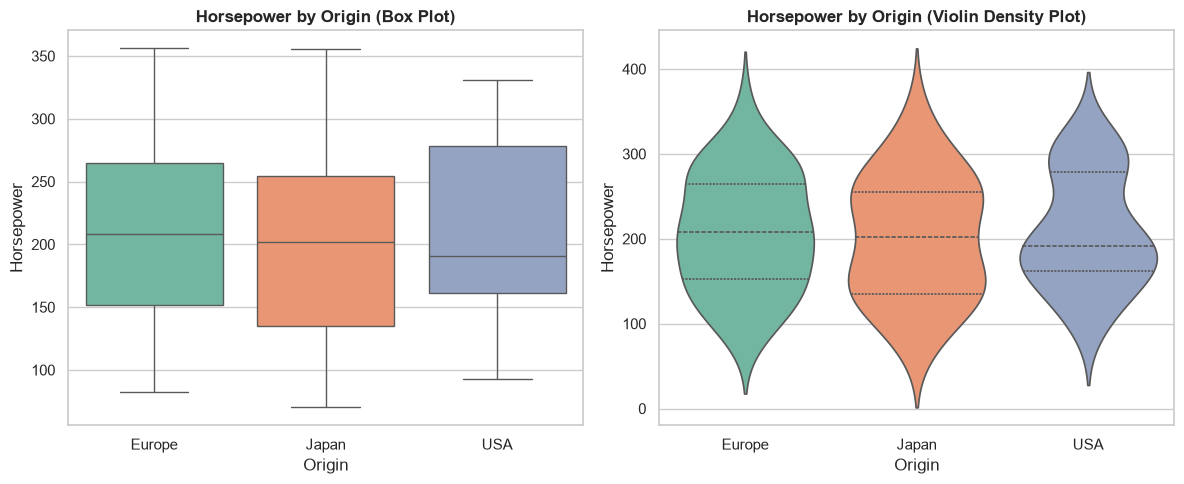

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Box Plot
sns.boxplot(data=df_cars, x='Origin', y='Horsepower', hue='Origin', palette='Set2', legend=False, ax=ax1)
ax1.set_title("Horsepower by Origin (Box Plot)", fontweight='bold')

# Violin Plot with inner quartiles
sns.violinplot(data=df_cars, x='Origin', y='Horsepower', hue='Origin', palette='Set2', legend=False, inner='quartile', ax=ax2)
ax2.set_title("Horsepower by Origin (Violin Density Plot)", fontweight='bold')

plt.tight_layout()
plt.show()

### Summary & Next Steps
In this notebook, you mastered:
- 5D multivariate relational mapping with `scatterplot`.
- Bootstrap confidence interval plotting with `lineplot`.
- Comparing continuous variables across categories using box, violin, and strip plots.

**Next Notebook:** `03_matrix_plots_and_correlation_heatmaps.ipynb` — Correlation matrices, masked heatmaps, and hierarchical clustermaps for multicollinearity detection.